<a href="https://colab.research.google.com/github/Abidullha/ReX-GNN/blob/main/ReX_GNN_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Environment Setup: PyTorch + PyG

In [3]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())


PyTorch version: 2.6.0+cu124
GPU available: True


Install PyG

In [4]:
# PyG install command (if needed)
!pip install torch-geometric -q

# 🔢 Python Libraries: NumPy, Pandas, Matplotlib

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

traffic = np.array([100, 130, 150, 140, 110])
moving_avg = np.convolve(traffic, np.ones(3)/3, mode='valid')
print("Moving Average:", moving_avg)


Moving Average: [126.66666667 140.         133.33333333]


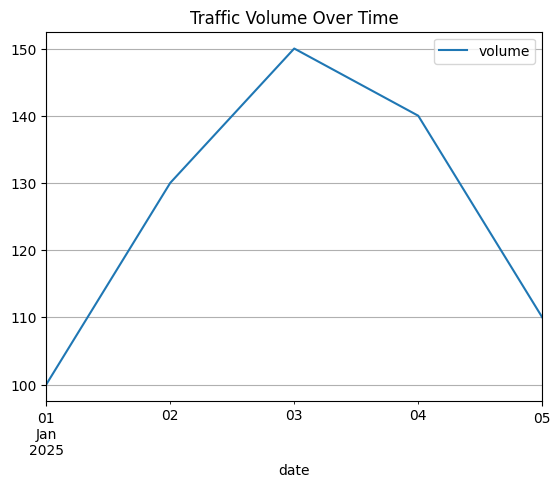

In [6]:
# Time-series plot
dates = pd.date_range("2025-01-01", periods=5)
df = pd.DataFrame({'date': dates, 'volume': traffic}).set_index('date')
df.plot()
plt.title("Traffic Volume Over Time")
plt.grid(True)
plt.show()


# 🔗 Graph Construction with PyTorch Geometric


In [8]:
from torch_geometric.data import Data

x = torch.tensor([[60, 100], [45, 130], [50, 120], [70, 80]], dtype=torch.float)
edge_index = torch.tensor([[0, 1, 2, 3, 0], [1, 2, 3, 0, 2]], dtype=torch.long)
edge_attr = torch.tensor([[1.0], [0.5], [1.2], [0.7], [0.9]], dtype=torch.float)

graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
print(graph)


Data(x=[4, 2], edge_index=[2, 5], edge_attr=[5, 1])


# 🤖 Mini Regression: Predicting Traffic Volume from Hour


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = np.array([[i] for i in range(24)])
y = np.array([80, 60, 40, 30, 25, 20, 30, 60, 120, 150, 160, 170,
              180, 190, 170, 160, 140, 130, 110, 100, 90, 100, 120, 100])

X_train, X_test = X[:19], X[19:]
y_train, y_test = y[:19], y[19:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


MAE: 97.74, RMSE: 98.37


## Notes:
- Trained a linear regression model on simple hourly traffic data
- Metrics like MAE and RMSE show prediction error
- These metrics will be used to evaluate ReX-GNN vs baselines


## 🧠 Mini Neural Network Regression in PyTorch

In this section, we build and train a simple neural network using PyTorch.

- The goal is to **predict traffic volume** based on the hour of the day (0–23).
- The input `X` represents the hour, and the target `y` is the actual traffic volume.
- The network consists of:
  - A fully connected `Linear` layer
  - A `ReLU` activation function
  - An output layer predicting traffic volume

We train the model using **Mean Squared Error (MSE)** loss and the **Adam optimizer** over 300 epochs.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# Simulated data: hours of day → traffic volume
X = torch.arange(0, 24).float().reshape(-1, 1)
y = torch.tensor([80, 60, 40, 30, 25, 20, 30, 60, 120, 150, 160, 170,
                  180, 190, 170, 160, 140, 130, 110, 100, 90, 100, 120, 100]).float().reshape(-1, 1)

# Define a small neural network
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(300):
    model.train()
    y_pred = model(X)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.2f}")


Epoch 0: Loss = 13968.47
Epoch 50: Loss = 3132.09
Epoch 100: Loss = 2947.29
Epoch 150: Loss = 2804.73
Epoch 200: Loss = 2670.94
Epoch 250: Loss = 2563.64


## 📈 Visualizing the Model's Predictions

Now that the neural network is trained, we’ll evaluate its performance by plotting:

- The **true traffic volumes** for each hour
- The **predicted values** from the neural network

This helps us visually assess how well the model has learned the time-based traffic pattern. The closer the two curves are, the better the model's performance.


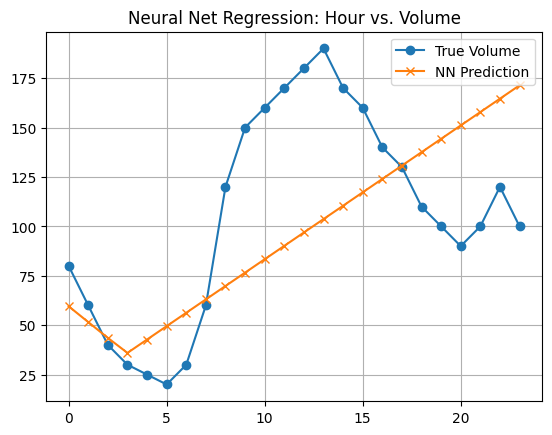

In [2]:
import matplotlib.pyplot as plt

model.eval()
preds = model(X).detach().numpy()

plt.plot(X.numpy(), y.numpy(), label='True Volume', marker='o')
plt.plot(X.numpy(), preds, label='NN Prediction', marker='x')
plt.legend()
plt.title("Neural Net Regression: Hour vs. Volume")
plt.grid(True)
plt.show()
